# Plan warsztatu

1. Co mierzy EEG?
2. Co to są Event-Related Potentials?
3. Rzut oka na nasz paradygmat
4. Google Colab, Python, MNE
5. Ładowanie danych
6. Preprocessing (i dlaczego jest to temat na osobne spotkanie)
7. Wizualizacja
8. Epoki
9. Uśrednianie
10. Peak measures
11. Metody statystyczne

In [ ]:
# tylko na google colab
!wget https://github.com/k-basinski/erp_tutorial/raw/refs/heads/main/data/raw.fif -P data
!wget https://github.com/k-basinski/erp_tutorial/raw/refs/heads/main/data/standards-epo.fif -P data
!wget https://github.com/k-basinski/erp_tutorial/raw/refs/heads/main/data/deviants-epo.fif -P data

!pip install mne

In [53]:
import mne

## Załadujmy surowe dane

In [54]:
raw = mne.io.read_raw_fif('data/raw.fif')

Opening raw data file data/raw.fif...
Isotrak not found
    Range : 0 ... 5999 =      0.000 ...    59.990 secs
Ready.


In [55]:
raw.plot()

Using pyopengl with version 3.1.6


Channels marked as bad:
none


## Preprocessing...

(i dlaczego jest to temat na osobne spotkanie)

In [25]:
standards = mne.read_epochs('data/standards-epo.fif')
deviants = mne.read_epochs('data/deviants-epo.fif')

Reading /Users/kbas/cloud/son/erp_tutorial/data/standards-epo.fif ...
    Found the data of interest:
        t =    -100.00 ...     490.00 ms
        0 CTF compensation matrices available
Not setting metadata
649 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/kbas/cloud/son/erp_tutorial/data/deviants-epo.fif ...
    Found the data of interest:
        t =    -100.00 ...     490.00 ms
        0 CTF compensation matrices available
Not setting metadata
134 matching events found
No baseline correction applied
0 projection items activated


In [26]:
standards.info

Measurement date,"września 03, 2024 13:21:15 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,67 points
Good channels,"64 EEG, 2 EOG, 1 Stimulus"
Bad channels,None
EOG channels,"EXG1, EXG2"
ECG channels,Not available
Sampling frequency,100.00 Hz
Highpass,0.20 Hz
Lowpass,30.00 Hz


In [ ]:
standards.plot()

Using pyopengl with version 3.1.6


Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


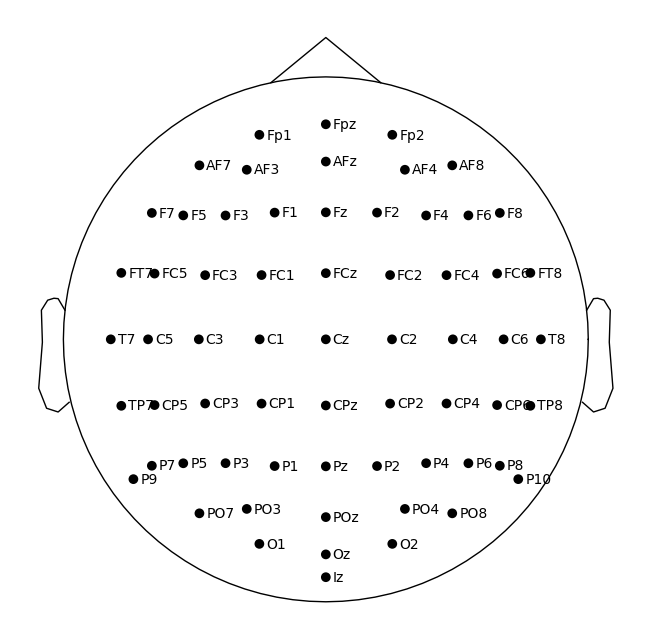

In [56]:
standards.get_montage().plot();

In [57]:
standards_data = standards.get_data(copy=False)
print(f'Kształt naszej tabeli: {standards_data.shape}\n')
print(standards_data)

Kształt naszej tabeli: (649, 67, 60)

[[[-2.65812560e-06 -4.00143875e-07  3.41637860e-06 ... -2.38167140e-05
   -2.52649697e-05 -2.04553180e-05]
  [-5.54889084e-06 -2.50864173e-06  3.64143875e-06 ... -2.06179484e-05
   -2.18828864e-05 -2.15814889e-05]
  [-3.99410010e-06  1.05792549e-06 -9.86685109e-07 ... -1.29601103e-05
   -1.60454820e-05 -1.98499474e-05]
  ...
  [ 5.37117958e-05 -7.63004500e-05  3.26781410e-05 ... -5.46235287e-06
    2.14745069e-05  1.00019734e-05]
  [ 5.76222483e-05 -7.57545931e-05  3.48416179e-05 ...  1.05113031e-07
    3.02654244e-05  2.11499464e-05]
  [ 1.76652119e-01 -1.90997675e-01  2.08634913e-01 ... -4.57415469e-02
    4.71017733e-02 -4.84554693e-02]]

 [[-1.40772590e-05 -1.06933576e-05 -4.51800861e-06 ... -8.04098363e-06
   -5.85107819e-06 -1.42168767e-06]
  [-1.08370341e-05 -6.91569767e-06 -2.91305037e-06 ... -8.87624174e-06
   -5.83433757e-06 -1.45444892e-06]
  [-1.52053713e-06 -4.19213450e-07  2.57237093e-06 ... -4.48107858e-06
   -3.47980313e-06  5.50754

## Uśrednianie

In [34]:
standards_avg = standards.average()
deviants_avg = deviants.average()

# jaki kształt mamy teraz?
standards_avg.get_data().shape

(64, 60)

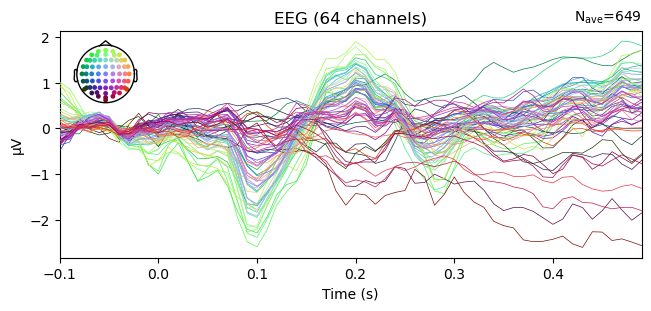

In [36]:
standards_avg.plot();

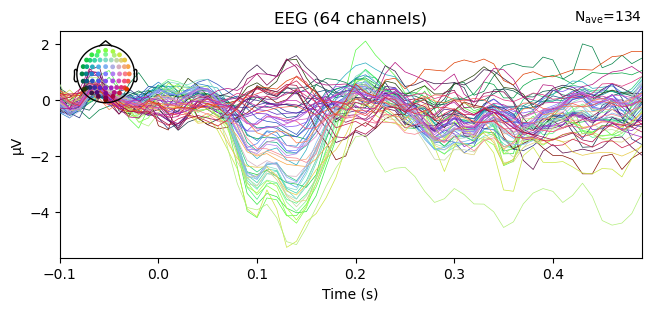

In [37]:
deviants_avg.plot();

No projector specified for this dataset. Please consider the method self.add_proj.


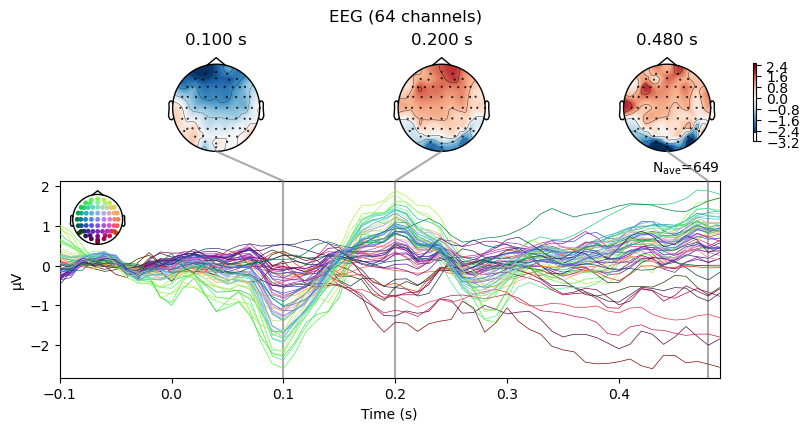

In [39]:
standards_avg.plot_joint();

No projector specified for this dataset. Please consider the method self.add_proj.


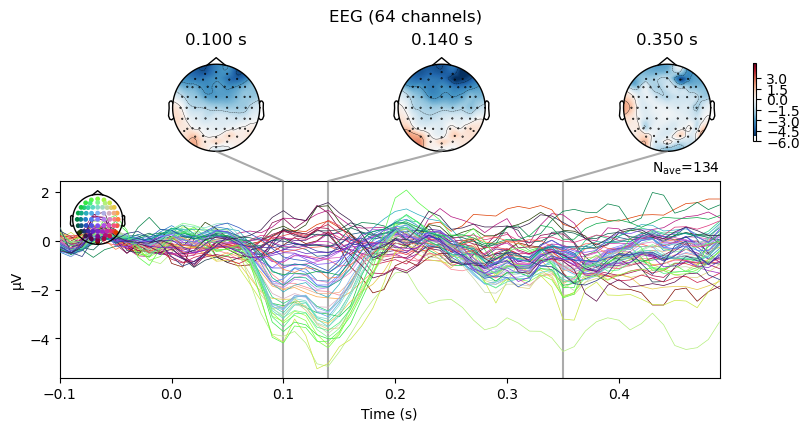

In [40]:
deviants_avg.plot_joint();

In [44]:
mismatch = mne.combine_evoked([deviants_avg, standards_avg], weights=[1, -1])


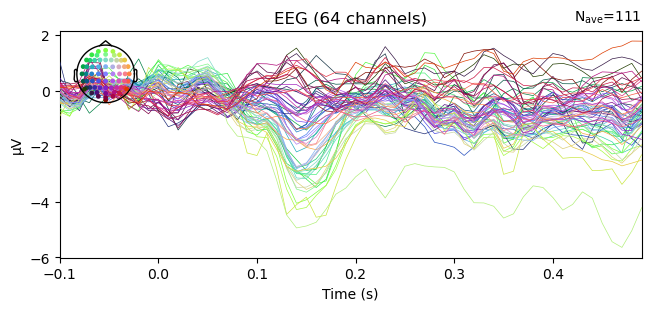

In [45]:
mismatch.plot();

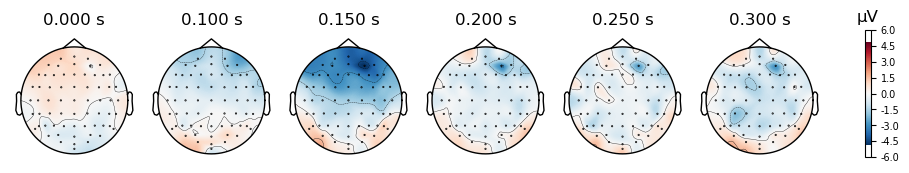

In [48]:
mismatch.plot_topomap([.0, .1, .15,.2, .25, .3]);

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


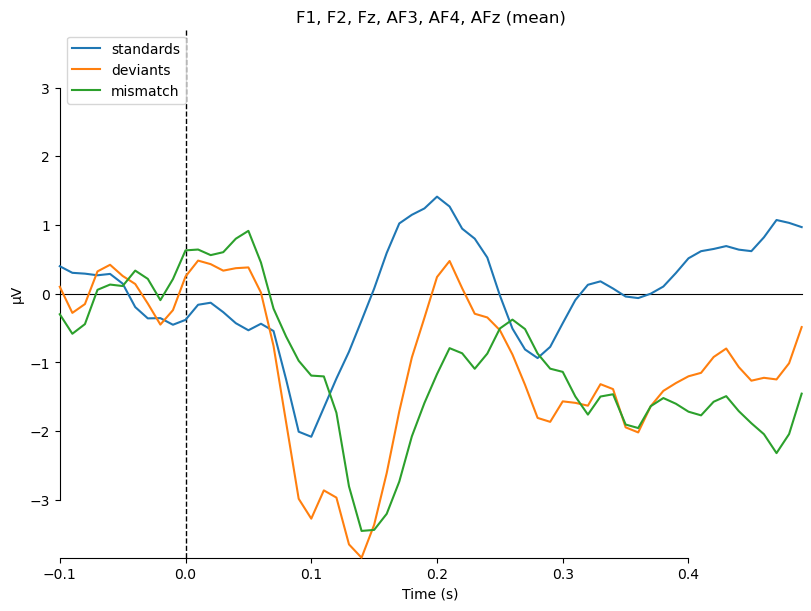

[<Figure size 800x600 with 1 Axes>]

In [50]:
evkds = {
    'standards': standards_avg,
    'deviants': deviants_avg,
    'mismatch': mismatch
}

mne.viz.plot_compare_evokeds(evkds, picks=['F1', 'F2', 'Fz', 'AF3', 'AF4', 'AFz'], combine='mean')

### W prawdziwym badaniu mamy więcej niż jeden mózg

![](img/std_dev2.png)

### Możemy też porównać między sobą warunki eksperymentalne

![](img/std_dev2.png)

## A co ze statystyką?

## Metoda klasyczna - peak measures

- Wybieramy opisany w literaturze potencjał wywołany (np. MMN, N400, P3b)
- **Na podstawie literatury** określamy jego latencję (przedział czasowy), walencję (+/-) i topografię (w których elektrodach go szukać)
- Szukamy w naszych danych __peaków__ (załamków?) - lokalnych minimów/maksimów
- Osobno dla każdego badanego określamy amplitudę (np. średnią, pole pod krzywą itd.) i/lub latencję peaku (załamka?)
- Otrzymujemy pojedyńcze liczby, które wrzucamy do analizy statystycznej (np. ANOVA, modele mieszane)

![](img/peaks.png)

![](img/peaks2.png)

### Metoda nowocześniejsza - mass-univariate approach/cluster-based permutations

Wykorzystujemy wszystkie punkty danych i nie przyjmujemy a'priori żadnych hipotez odnośnie istnienia ERPów.

![](img/cluster_ftest.png)